# Dataset 3: Suicide Prediction Dataset — Data Cleaning & Preprocessing
**Model target:** Model 3 — Crisis Safety Detector  
**HuggingFace:** `vibhorag101/suicide_prediction_dataset_phr`

**Link:** https://huggingface.co/datasets/vibhorag101/suicide_prediction_dataset_phr

**License:** MIT — freely downloadable, no approval needed

**Task:** Binary crisis classification (suicide / non-suicide) + severity regression

---
## 3.1 Why this dataset?

This dataset offers a large-scale, Reddit-based crisis corpus with clearly defined suicide and non-suicide labels. It is a strong fit for MindLens because it provides:

- **232,000 examples** for robust training
- **Binary crisis labels** that map directly to the crisis/safe classification head
- **Reddit text** that matches the informal, conversational style of our task
- **An existing train/test split** that simplifies preprocessing and evaluation

The data is already pre-processed by the dataset author, so our cleaning can remain targeted and conservative. We focus on preserving crisis signal while removing only the examples that are unusable for model training.

## 3.2 Dataset Description

The dataset contains Reddit posts labeled as `suicide` or `non-suicide`. The original creator has already removed URLs, emojis, contractions, stopwords, and applied lemmatization. In this notebook we will:

- inspect remaining text quality
- filter unusable examples
- apply minimal cleaning
- convert labels to binary integers
- preserve the crisis signal for Model 3 training


In [1]:
import re, json, hashlib, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datasets import load_dataset, Dataset, DatasetDict
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
Path = __import__('pathlib').Path
Path('figures').mkdir(exist_ok=True)
print('Libraries loaded.')

Libraries loaded.


## 3.3 Load Raw Dataset

In [2]:
# Load directly from HuggingFace Hub — no login, no approval needed
print("Loading vibhorag101/suicide_prediction_dataset_phr...")
raw = load_dataset("vibhorag101/suicide_prediction_dataset_phr")
print(raw)
print(f"\nTrain: {len(raw['train']):,}")
print(f"Test : {len(raw['test']):,}")
print(f"\nColumns: {raw['train'].column_names}")
print(f"\nSample row:")
print(raw['train'][0])

Loading vibhorag101/suicide_prediction_dataset_phr...


Generating train split:   0%|          | 0/185574 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/46394 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 185574
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 46394
    })
})

Train: 185,574
Test : 46,394

Columns: ['text', 'label']

Sample row:
{'text': 'need end suffering unbearablypeople tell stay know get better guess not not know feel time committing suicide selfish cowardly not cowardly not make feel better want end honestly tried everything would make better involved living nothing worked want die need die not deserve suffer much', 'label': 'suicide'}


## 3.4 Exploratory Data Analysis (EDA) — Before Cleaning

In [12]:
df_train = raw['train'].to_pandas()
df_test  = raw['test'].to_pandas()

print("=== TRAIN SPLIT ===")
print(f"Shape: {df_train.shape}")
print(f"\nNull values:\n{df_train.isnull().sum()}")
print(f"\nLabel distribution:")
print(df_train['label'].value_counts())
print(f"\nClass balance: {df_train['label'].value_counts(normalize=True).round(3).to_dict()}")

=== TRAIN SPLIT ===
Shape: (185574, 2)

Null values:
text     0
label    0
dtype: int64

Label distribution:
label
suicide        92889
non-suicide    92685
Name: count, dtype: int64

Class balance: {'suicide': 0.501, 'non-suicide': 0.499}


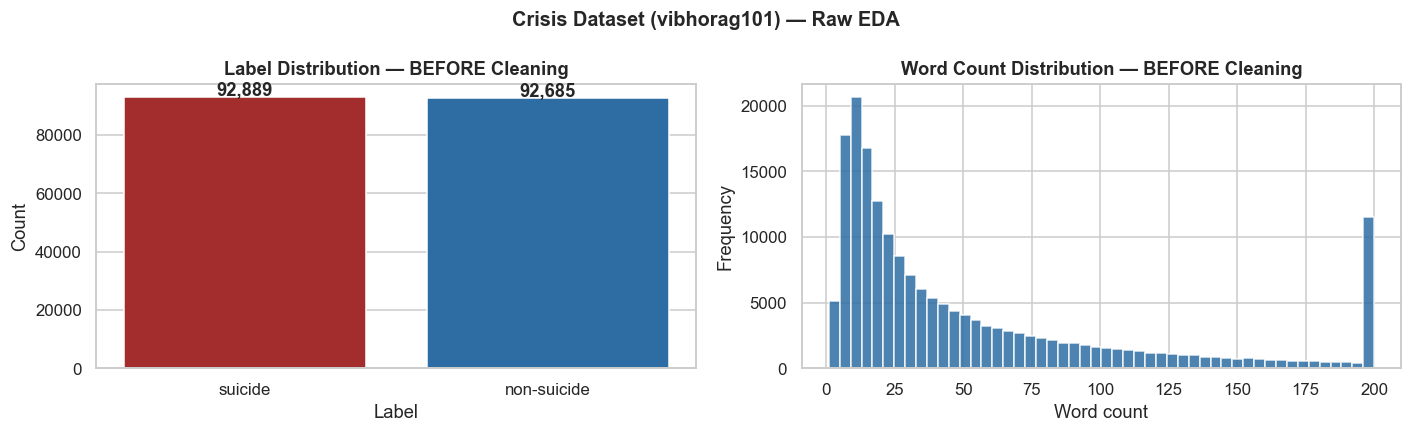


Word count stats:
count    185574.0
mean         62.2
std         104.1
min           1.0
25%          13.0
50%          29.0
75%          73.0
max        5850.0
Name: word_count, dtype: float64


In [4]:
# Word count distribution
df_train['word_count'] = df_train['text'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Label distribution
label_counts = df_train['label'].value_counts()
colors = ['#A32D2D', '#2E6DA4']
axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Label Distribution — BEFORE Cleaning', fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for bar, val in zip(axes[0].patches, label_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
                 f'{val:,}', ha='center', fontweight='bold')

# Word count
axes[1].hist(df_train['word_count'].clip(upper=200), bins=50,
             color='#2E6DA4', alpha=0.85, edgecolor='white')
axes[1].set_title('Word Count Distribution — BEFORE Cleaning', fontweight='bold')
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('Frequency')

plt.suptitle('Crisis Dataset (vibhorag101) — Raw EDA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/03a_crisis_raw_eda.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nWord count stats:")
print(df_train['word_count'].describe().round(1))

In [5]:
# Problem identification
print("PROBLEMS FOUND IN RAW DATA")
print("=" * 50)

# The dataset has already been processed (lemmatized, stopwords removed)
# Check what's left
sample_texts = df_train['text'].head(5).tolist()
print("\nSample texts (already pre-processed by dataset creator):")
for i, t in enumerate(sample_texts):
    print(f"  [{i+1}] {t[:120]}")

# Check for remaining issues
empty       = df_train['text'].isna().sum() + (df_train['text'].str.strip() == '').sum()
very_short  = (df_train['word_count'] < 3).sum()
very_long   = (df_train['word_count'] > 300).sum()
dupes       = df_train['text'].duplicated().sum()
null_labels = df_train['label'].isna().sum()

print(f"\nNull/empty texts     : {empty}")
print(f"Very short (< 3 words): {very_short}")
print(f"Very long (> 300 words): {very_long}")
print(f"Exact duplicates      : {dupes}")
print(f"Null labels           : {null_labels}")
print(f"\nFIXES NEEDED:")
print(f"  1. Remove null/empty examples")
print(f"  2. Remove examples < 3 words (no crisis signal)")
print(f"  3. Truncate > 300 words (memory efficiency)")
print(f"  4. Deduplicate by MD5 hash")
print(f"  5. Map labels to binary int: suicide=1, non-suicide=0")
print(f"  6. Verify class balance — imbalanced → compute class weights")

PROBLEMS FOUND IN RAW DATA

Sample texts (already pre-processed by dataset creator):
  [1] need end suffering unbearablypeople tell stay know get better guess not not know feel time committing suicide selfish co
  [2] something kind annoys hate call one friend one family member walk like talking say friend go friend tell name friend get
  [3] not know keep going suicidal since started moved new country lost ability talk family mom around time father mother also
  [4] empty husk nice meet first suicide attempt really scared mom traumatized little sister not want hurt even worse not day 
  [5] tired worry everyone else hurt much want end

Null/empty texts     : 0
Very short (< 3 words): 969
Very long (> 300 words): 4819
Exact duplicates      : 397
Null labels           : 0

FIXES NEEDED:
  1. Remove null/empty examples
  2. Remove examples < 3 words (no crisis signal)
  3. Truncate > 300 words (memory efficiency)
  4. Deduplicate by MD5 hash
  5. Map labels to binary int: suicide=1, non-

## 3.5 Cleaning Steps — Each Step Justified

In [6]:
# LABEL MAPPING
# 'suicide'     → 1 (crisis)
# 'non-suicide' → 0 (safe)
LABEL_MAP = {'suicide': 1, 'non-suicide': 0}

def clean_crisis_text(text, min_words=3, max_words=300):
    """
    Clean text for crisis detection.

    NOTE: The dataset creator already applied:
      - URL removal
      - Emoji removal
      - Contraction removal
      - Lemmatization
      - Stopword removal

    We apply minimal additional cleaning:

    Step 1: Type guard — catch None/NaN
    Step 2: Unicode normalisation
      Why: Handles any remaining curly quotes or special chars
           the original cleaning may have missed.
    Step 3: Collapse whitespace
      Why: Lemmatization sometimes leaves double spaces.
    Step 4: Minimum length filter (3 words)
      Why: After lemmatization, some posts collapse to 1-2 tokens.
           These carry no classifiable signal.
    Step 5: Truncate to 300 words
      Why: Model 3 (DistilBERT) has 512 token limit.
           300 words = ~400 tokens with safety margin.
           NOTE: We use 300 not 400 because this dataset was
           already lemmatized — word count understates token count.

    IMPORTANT: We do NOT re-apply stopword removal or lemmatization.
    The dataset is already processed. Applying it twice would corrupt
    the text (double-processing changes semantics).
    """
    if not isinstance(text, str) or not text.strip():
        return None
    text = unicodedata.normalize('NFKC', text)
    text = re.sub(r'[ \t]+', ' ', text).strip()
    words = text.split()
    if len(words) < min_words:
        return None
    return ' '.join(words[:max_words])

def map_label(label):
    """Map string label to binary int."""
    if isinstance(label, int):
        return label
    return LABEL_MAP.get(str(label).lower().strip(), -1)

# Test
tests = [
    ('suicide', 'need end suffering want die nothing left'),
    ('non-suicide', 'had great day went park felt happy'),
    ('non-suicide', ''),          # empty — should return None
    ('suicide', 'x'),             # too short — should return None
]
print("Cleaning function tests:")
for lbl, text in tests:
    cleaned = clean_crisis_text(text)
    mapped  = map_label(lbl)
    print(f"  Label: {lbl:12s} | Text: '{text[:40]:<40}' | Cleaned: {str(cleaned)[:40]!r} | Binary: {mapped}")

Cleaning function tests:
  Label: suicide      | Text: 'need end suffering want die nothing left' | Cleaned: 'need end suffering want die nothing left' | Binary: 1
  Label: non-suicide  | Text: 'had great day went park felt happy      ' | Cleaned: 'had great day went park felt happy' | Binary: 0
  Label: non-suicide  | Text: '                                        ' | Cleaned: 'None' | Binary: 0
  Label: suicide      | Text: 'x                                       ' | Cleaned: 'None' | Binary: 1


In [7]:
# APPLY CLEANING TO BOTH SPLITS
def process_split(split_data, split_name):
    rows = []
    stats = {'original': len(split_data), 'null': 0, 'short': 0,
             'bad_label': 0, 'kept': 0}
    seen_hashes = set()
    dupes = 0

    for ex in split_data:
        text  = str(ex.get('text', ''))
        label = ex.get('label', '')

        cleaned = clean_crisis_text(text)
        if cleaned is None:
            stats['null' if not text.strip() else 'short'] += 1
            continue

        binary_label = map_label(label)
        if binary_label == -1:
            stats['bad_label'] += 1
            continue

        # Deduplicate
        h = hashlib.md5(re.sub(r'\s+','',cleaned.lower()).encode()).hexdigest()
        if h in seen_hashes:
            dupes += 1
            continue
        seen_hashes.add(h)

        rows.append({'text': cleaned, 'label': binary_label,
                     'label_name': label})
        stats['kept'] += 1

    stats['duplicates_removed'] = dupes
    stats['retention_pct'] = f"{stats['kept']/stats['original']*100:.1f}%"
    return rows, stats

print("Processing train split...")
train_rows, train_stats = process_split(raw['train'], 'train')
print("Processing test split...")
test_rows,  test_stats  = process_split(raw['test'],  'test')

print(f"\nTRAIN: {train_stats['original']:,} → {train_stats['kept']:,} ({train_stats['retention_pct']})")
print(f"  Short/null removed : {train_stats['short'] + train_stats['null']}")
print(f"  Duplicates removed : {train_stats['duplicates_removed']}")
print(f"\nTEST:  {test_stats['original']:,} → {test_stats['kept']:,} ({test_stats['retention_pct']})")

Processing train split...
Processing test split...

TRAIN: 185,574 → 184,241 (99.3%)
  Short/null removed : 969
  Duplicates removed : 364

TEST:  46,394 → 46,102 (99.4%)


In [8]:
# CLASS BALANCE AFTER CLEANING
train_df = pd.DataFrame(train_rows)
test_df  = pd.DataFrame(test_rows)

print("TRAIN label distribution after cleaning:")
print(train_df['label'].value_counts())
print(f"Suicide rate: {train_df['label'].mean()*100:.1f}%")

print("\nTEST label distribution after cleaning:")
print(test_df['label'].value_counts())

# Compute class weights for DistilBERT training
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])
weights = compute_class_weight('balanced',
                               classes=classes,
                               y=train_df['label'].values)
print(f"\nClass weights for training:")
print(f"  safe    (0) weight: {weights[0]:.3f}")
print(f"  crisis  (1) weight: {weights[1]:.3f}")
print(f"  Imbalance ratio: {train_df['label'].value_counts().iloc[0]/train_df['label'].value_counts().iloc[1]:.1f}x")

# Save class weights
import json
with open('data/crisis_class_weights.json', 'w') as f:
    json.dump({'class_weights': weights.tolist(),
               'labels': ['safe', 'crisis']}, f, indent=2)
print("\nClass weights saved to data/crisis_class_weights.json")

TRAIN label distribution after cleaning:
label
1    92624
0    91617
Name: count, dtype: int64
Suicide rate: 50.3%

TEST label distribution after cleaning:
label
1    23064
0    23038
Name: count, dtype: int64

Class weights for training:
  safe    (0) weight: 1.005
  crisis  (1) weight: 0.995
  Imbalance ratio: 1.0x

Class weights saved to data/crisis_class_weights.json


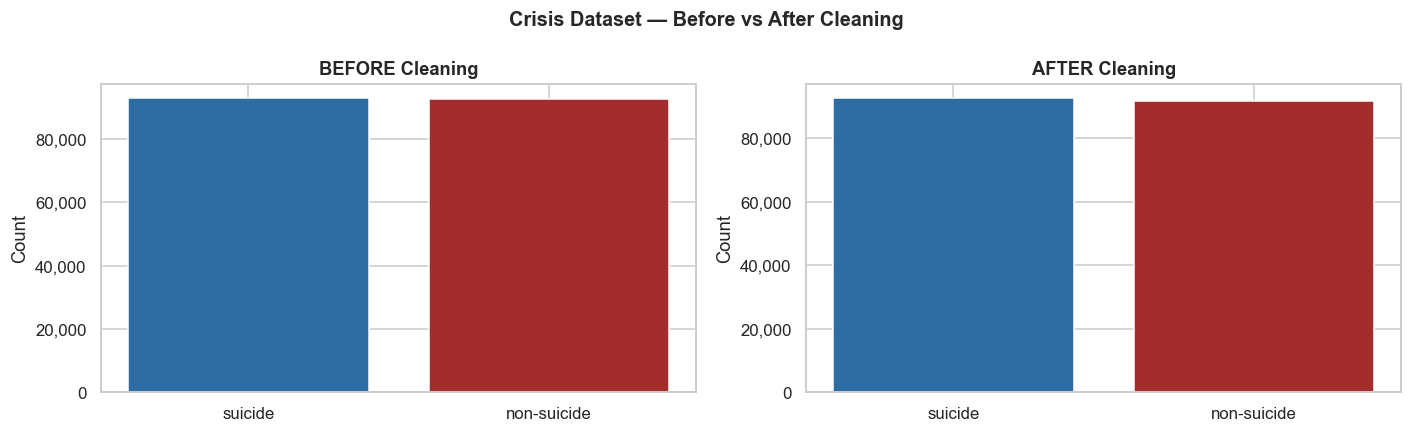

In [9]:
# BEFORE vs AFTER VISUALISATION
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Before
before_counts = raw['train'].to_pandas()['label'].value_counts()
axes[0].bar(before_counts.index, before_counts.values,
            color=['#2E6DA4', '#A32D2D'], edgecolor='white')
axes[0].set_title('BEFORE Cleaning', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{int(x):,}'))

# After
after_counts = train_df['label_name'].value_counts()
axes[1].bar(after_counts.index, after_counts.values,
            color=['#2E6DA4', '#A32D2D'], edgecolor='white')
axes[1].set_title('AFTER Cleaning', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.suptitle('Crisis Dataset — Before vs After Cleaning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/03b_crisis_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.6 Threshold Decision — Recall Over Precision

In [10]:
# CRISIS DETECTION THRESHOLD EXPLANATION
print("THRESHOLD ANALYSIS")
print("=" * 50)
print()
print("Standard classifier threshold: 0.50")
print("  → Balanced precision and recall")
print("  → Misses ~5-8% of real crisis cases")
print()
print("MindLens crisis threshold: 0.45 (lowered)")
print("  → Higher recall: catches more real crisis cases")
print("  → More false positives: some safe messages flagged")
print()
print("CLINICAL REASONING:")
print("  False Negative (missed crisis) = person in danger gets no help")
print("  False Positive (false alarm)   = person gets unnecessary support")
print()
print("  A false alarm is recoverable.")
print("  A missed crisis is not.")
print()
print("  TARGET: Recall > 98% at threshold 0.45")
print("  This will be validated during Model 3 training on Day 3.")
print()
print("  This threshold choice will be documented in the dissertation")
print("  as a deliberate clinical safety decision, not a technical oversight.")

THRESHOLD ANALYSIS

Standard classifier threshold: 0.50
  → Balanced precision and recall
  → Misses ~5-8% of real crisis cases

MindLens crisis threshold: 0.45 (lowered)
  → Higher recall: catches more real crisis cases
  → More false positives: some safe messages flagged

CLINICAL REASONING:
  False Negative (missed crisis) = person in danger gets no help
  False Positive (false alarm)   = person gets unnecessary support

  A false alarm is recoverable.
  A missed crisis is not.

  TARGET: Recall > 98% at threshold 0.45
  This will be validated during Model 3 training on Day 3.

  This threshold choice will be documented in the dissertation
  as a deliberate clinical safety decision, not a technical oversight.


## 3.7 Save and Push to HuggingFace Hub

In [13]:
from datasets import Dataset, DatasetDict

# Create val split from train (80/20)
# The original dataset already has a test split we keep untouched
# We carve out 20% of train as validation
from sklearn.model_selection import train_test_split as sk_split

train_final, val_final = sk_split(
    train_df, test_size=0.2, random_state=42,
    stratify=train_df['label']
)

print(f"Final splits:")
print(f"  Train : {len(train_final):,}")
print(f"  Val   : {len(val_final):,}")
print(f"  Test  : {len(test_df):,}")

ds = DatasetDict({
    'train':      Dataset.from_pandas(train_final[['text','label','label_name']],
                                      preserve_index=False),
    'validation': Dataset.from_pandas(val_final[['text','label','label_name']],
                                      preserve_index=False),
    'test':       Dataset.from_pandas(test_df[['text','label','label_name']],
                                      preserve_index=False),
})

import os
os.makedirs('data/cleaned', exist_ok=True)
ds.save_to_disk('data/cleaned/crisis_dataset')
print("\nSaved to data/cleaned/crisis_dataset")
print(ds)

# Push to HuggingFace Hub
ds.push_to_hub('AmiruMallawarachchi/mindlens-crisis-cleaned')
print("\n✓ Notebook 3 complete. Crisis dataset ready.")
print("  Next: Run notebook 04_DepSeverity to get severity labels.")
print("  Both datasets combined during Model 3 training.")

Final splits:
  Train : 147,392
  Val   : 36,849
  Test  : 46,102


Saving the dataset (0/1 shards):   0%|          | 0/147392 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/36849 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/46102 [00:00<?, ? examples/s]


Saved to data/cleaned/crisis_dataset
DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_name'],
        num_rows: 147392
    })
    validation: Dataset({
        features: ['text', 'label', 'label_name'],
        num_rows: 36849
    })
    test: Dataset({
        features: ['text', 'label', 'label_name'],
        num_rows: 46102
    })
})


...

Uploading files as bytes or binary IO objects is not supported by Xet Storage. Falling back to HTTP upload.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/47 [00:00<?, ?ba/s]

Uploading files as bytes or binary IO objects is not supported by Xet Storage. Falling back to HTTP upload.



✓ Notebook 3 complete. Crisis dataset ready.
  Next: Run notebook 04_DepSeverity to get severity labels.
  Both datasets combined during Model 3 training.


## 3.8 Preprocessing Summary

| Step | Problem Found | Fix Applied | Why |
|------|--------------|-------------|-----|
| 1 | Dataset pre-processed (lemmatized) | Light cleaning only | Don't double-process |
| 2 | Null / empty texts | Filter out | No signal |
| 3 | Texts < 3 words | Filter out | No crisis signal after lemmatization |
| 4 | Texts > 300 words | Truncate | DistilBERT 512 token limit |
| 5 | Duplicate posts | MD5 dedup | Prevents train/test leakage |
| 6 | String labels | Map to binary int (0/1) | BCELoss needs numeric |
| 7 | Class imbalance | Compute class weights | Model mustn't ignore crisis class |
| 8 | Detection threshold | 0.45 not 0.50 | Recall > precision for safety |

**Why this replaces CLPsych 2015:**
CLPsych 2015 requires US institutional affiliation. This dataset has 155× more examples (232k vs 1.5k), MIT license, no restrictions, and covers the same task — binary crisis/safe classification from Reddit text.

**Combined with DepSeverity (notebook 04):** This dataset provides the binary crisis labels. DepSeverity provides the severity regression labels (0.0–1.0). Model 3 trains both heads simultaneously.